# ¡Criminalidad en Buenos Aires!


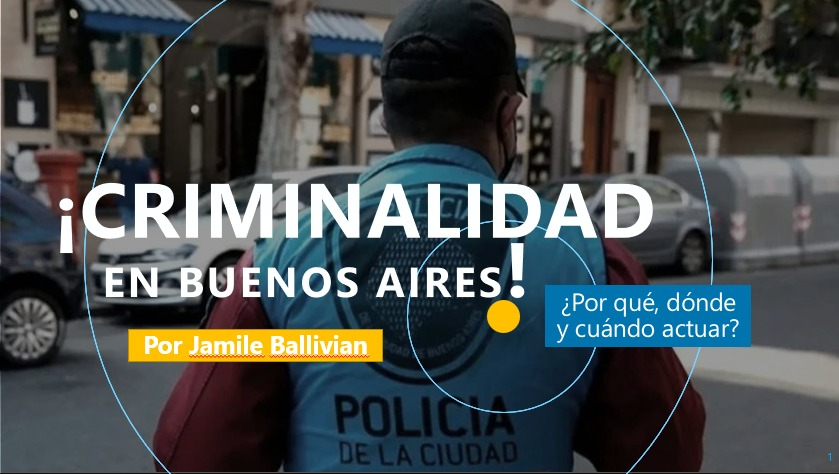


# Abstract
>El presente estudio tiene como objetivo analizar la influencia de diversas variables, como el lugar, la hora, el día de la semana y el mes, en la probabilidad de ser víctima de un delito en la ciudad de Buenos Aires. La motivación central de este análisis es contribuir a la toma de decisiones estratégicas para los responsables de la seguridad en la ciudad, con el objetivo de contrarrestar el aumento de la inseguridad localizada.

>Utilizando un conjunto de datos proporcionado por el gobierno de la ciudad, se pretende desarrollar un modelo predictivo utilizando Python, con el fin de comprender mejor los patrones y las tendencias asociadas a la criminalidad en esta área específica.

>El dataset abarca información detallada, incluyendo la fecha y la franja horaria de los incidentes, el día de la semana, el tipo de delito y el barrio correspondiente. Estos elementos permitirán realizar un análisis temporal y geoespacial integral para identificar posibles correlaciones y patrones emergentes.

>La variable temporal se explorará de varias maneras. Se investigará si la ocurrencia de ciertos tipos de delitos varía según el día de la semana, el mes o incluso la hora del día. La temporalidad puede revelar tendencias estacionales, comportamientos cíclicos o eventos particulares que podrían influir en la tasa de criminalidad.

>Asimismo, se analizará la ubicación geográfica de los delitos, evaluando si la incidencia varía según los distintos barrios de Buenos Aires. Esto podría proporcionar información valiosa sobre la distribución espacial de la criminalidad y permitir la identificación de áreas de mayor riesgo.

>Para la creación del modelo predictivo, se utilizarán bibliotecas de machine learning en Python, como scikit-learn. Se implementarán algoritmos de clasificación para predecir la probabilidad de que ocurra un delito en función de las variables mencionadas. El proceso de modelado incluirá la división del conjunto de datos en conjuntos de entrenamiento y prueba, la selección de características relevantes y la evaluación del rendimiento del modelo.

>Los resultados de este estudio podrían tener implicaciones significativas para el diseño de estrategias de seguridad y la asignación eficiente de recursos en la ciudad de Buenos Aires. La comprensión de los factores que influyen en la probabilidad de ser víctima de un delito permitirá desarrollar enfoques más efectivos para la prevención y la gestión de la seguridad pública en la región, proporcionando información valiosa a los tomadores de decisiones en materia de seguridad en la ciudad.

# Objetivo
>>El objetivo primordial de este estudio es proporcionar información precisa y confiable para respaldar la toma de decisiones en la gestión de recursos para las fuerzas de seguridad. A través de un enfoque adaptado de análisis exploratorio de datos, se busca resaltar aspectos directamente relevantes para la seguridad pública. Este enfoque implica identificar patrones y tendencias específicas en la ocurrencia de diversos tipos de delitos, permitiendo una comprensión profunda de las dinámicas delictivas en la región.






# Problema comercial
>>¿En qué barrios se cometen más delitos?

>>¿Qué tipos de delitos son los más comunes?

>>¿La hora influye en la cantidad de delitos?

>>¿En qué época del año se registra la mayor y menor cantidad de delitos? ¿Por qué?

>>¿El día de la semana influye en la cantidad de delitos?


# Contexto comercial
>En diversos contextos comerciales y gubernamentales, la implementación de modelos predictivos para completar el subtipo de crímenes denunciados ofrece una amplia gama de aplicaciones y beneficios significativos. Desde agencias gubernamentales de seguridad y departamentos de policía hasta empresas de seguridad privada y consultoras de seguridad, estos modelos facilitan la mejora en la asignación de recursos, la respuesta eficiente a emergencias y el cumplimiento de normativas. Además, en municipios y agencias de gestión de emergencias, optimizan los costos operativos y fortalecen la gestión de incidentes, mientras que en unidades de análisis criminal y centros de inteligencia policial, proporcionan herramientas para la identificación proactiva de riesgos y la prevención del crimen. También son fundamentales para instituciones académicas y consultorías en políticas públicas, ya que permiten la formulación basada en evidencia de políticas de seguridad y la evaluación de impacto de programas comunitarios, promoviendo así el bienestar y la seguridad ciudadana de manera integral.

# Contexto análitico
> Desde un archivo .csv obtenido de la página web del gobierno de la ciudad de Buenos Aires que contiene los datos correspondientes a los delitos denunciados en el año 2022 y cuyo delimitador es la "," se procedió a cargar, transformar y preparar los datos con los que posteriormente se realizaron los análisis y gráficos.

Esta es la descripción de las variables del dataset:

* id-mapa; número de identificación del incidente.
* anio; año en el que ocurrió.
* mes: mes en el que ocurrió.
* dia: día de la semana en el que ocurrió.
* fecha: en la que ocurrió.
* franja: hora aproximada en la que ocurrió.
* tipo: tipo de delito.
* subtipo: subclasificación del tipo de delito. Ej: Tipo = Robo, Subtipo : Robo celular.
* uso_arma: si hubo uso de arma.
* uso_moto: si hubo uso de moto.
* barrio: barrio en el que ocurrió.
* comuna: comuna en la que ocurrió.
* latitud: dato de la ubicación donde ocurrió.
* longitud: dato de la ubicación donde ocurrió.
* cantidad: cantidad de incidentes.

Fuente del dataset: https://data.buenosaires.gob.ar/dataset/delitos/resource/3fbc3808-14c7-4559-8ba5-f68e919fee40

# Preguntas de interes.


>1. Preguntas de interes.
>> 1. ¿Qué delito se comete más en la ciudad?
>> 2. ¿En qué barrio se cometen más delitos?
>> 3. ¿En qué mes se cometen más delitos?


# Instalación e importación de las librerías a utilizar

In [15]:
# Importar las librerías.
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import csv
import os
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
import calendar


# Armado del dataframe

In [16]:
#Conecto a Google.
from google.colab import drive
drive.mount('/content/drive')

#Cargo los archivos.
ruta = '/content/drive/MyDrive/Coder Ds/Datasets/delitos_2022.csv'

# Creo el dataset
df = pd.read_csv(ruta)

# Elijo un estilo
plt.style.use('ggplot')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Data Wrangling

In [17]:
# Consulto los datos nulos
df.isnull().sum()

,0
id-mapa,0
anio,0
mes,0
dia,0
fecha,0
franja,47
tipo,0
subtipo,0
uso_arma,0
uso_moto,0


* Se eliminan las filas de los registros nulos de la columna franja por ser solo el 0.0003 % del total del df y estadísticamente no va a afectar.
* Se completan los valores nulos de la columna barrio con el valor "desconocido" por ser el 1.7 % del total de datos del df. Un número estadísticamente significativo.
Además, contienen datos de fecha y delito que van a ser importantes para el modelo cuando se analice por tiempo y por tipo de delito más adelante.
* Se eliminan las columnas con datos que no van a ser usados.
* Verificamos que no hay valores nulos.

In [18]:
# Relleno los valores nulos en la columna 'barrio' con 'desconocido'
df['barrio'].fillna('INDETERMINADO', inplace=True)
df['comuna'].fillna('0', inplace=True)
df['longitud'].fillna('0', inplace=True)
df['latitud'].fillna('0', inplace=True)

# Elimino las filas enteras donde se registran valores nulos en la columna franja.
df = df.dropna(subset=['franja'])

df.isnull().sum()

/tmp/ipython-input-1425564948.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['barrio'].fillna('INDETERMINADO', inplace=True)
/tmp/ipython-input-1425564948.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

,0
id-mapa,0
anio,0
mes,0
dia,0
fecha,0
franja,0
tipo,0
subtipo,0
uso_arma,0
uso_moto,0


 Se verifica la existencia de valores duplicados de la columna id-mapa.

In [19]:
# Verifico duplicados en la columna 'id-mapa'
duplicados = df['id-mapa'].duplicated()

# Cuento el número total de duplicados
numero_total_duplicados = duplicados.sum()

# Imprimo el los resultados

print("\nNúmero total de duplicados en la columna 'id-mapa':", numero_total_duplicados)


Número total de duplicados en la columna 'id-mapa': 0


Se imprime la información general del dataframe a utilizar para conocer su estructura y tipos de datos.

In [20]:
# Veo la información general del DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 140871 entries, 0 to 140917
Data columns (total 15 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   id-mapa   140871 non-null  int64  
 1   anio      140871 non-null  int64  
 2   mes       140871 non-null  object 
 3   dia       140871 non-null  object 
 4   fecha     140871 non-null  object 
 5   franja    140871 non-null  float64
 6   tipo      140871 non-null  object 
 7   subtipo   140871 non-null  object 
 8   uso_arma  140871 non-null  object 
 9   uso_moto  140871 non-null  object 
 10  barrio    140871 non-null  object 
 11  comuna    140871 non-null  object 
 12  latitud   140871 non-null  object 
 13  longitud  140871 non-null  object 
 14  cantidad  140871 non-null  int64  
dtypes: float64(1), int64(3), object(11)
memory usage: 17.2+ MB


Se puede ver que hay muchas columnas de tipo objeto y las vamos a cambiar a tipo categórico.
* Se convierte a formato fecha la columna fecha y se ordena el df en ordén cronológico.
* Se cambian los tipos de datos de las columnas mes, día, tipo, subtipo,  uso_arma, uso_moto y barrio de objeto a categoría.
*Se imprime la información general de df para verificar los cambios hechos.
* Se corrobora el cambio en las columnas nombradas arriba.

In [21]:
# Convierto la columna 'Date' a datetime
df['fecha'] = pd.to_datetime(df['fecha'])

# Ordeno por la variable tiempo
df = df.sort_values(by='fecha')

# Crear una nueva columna 'mes' extrayendo el mes de la columna de fecha
df['mes1'] = df['fecha'].dt.month

# Cambio el tipo de dato de las columnas de tipo objeto a categóricas y la columna franja de tipo float a categórica
columnas_a_cambiar = ['mes', 'dia', 'tipo', 'subtipo', 'uso_arma', 'uso_moto', 'barrio', 'franja']
df[columnas_a_cambiar] = df[columnas_a_cambiar].astype('category')

# Cambio el tipo de dato de las columnas de tipo objeto a float
columnas_a_cambiar2 = ['comuna', 'latitud', 'longitud']
df[columnas_a_cambiar2] = df[columnas_a_cambiar2].astype(float)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 140871 entries, 11274 to 140917
Data columns (total 16 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   id-mapa   140871 non-null  int64         
 1   anio      140871 non-null  int64         
 2   mes       140871 non-null  category      
 3   dia       140871 non-null  category      
 4   fecha     140871 non-null  datetime64[ns]
 5   franja    140871 non-null  category      
 6   tipo      140871 non-null  category      
 7   subtipo   140871 non-null  category      
 8   uso_arma  140871 non-null  category      
 9   uso_moto  140871 non-null  category      
 10  barrio    140871 non-null  category      
 11  comuna    140871 non-null  float64       
 12  latitud   140871 non-null  float64       
 13  longitud  140871 non-null  float64       
 14  cantidad  140871 non-null  int64         
 15  mes1      140871 non-null  int32         
dtypes: category(8), datetime64[ns](1), floa

Se revisa la forma del dataframe


In [22]:
# Obtener el shape del DataFrame
shape = df.shape

print("Número de filas:", shape[0])
print("Número de columnas:", shape[1])

Número de filas: 140871
Número de columnas: 16


# Análisis exploratorio de datos (EDA)


Se chequean los valores del df.

In [23]:
# Imprimo el df.
print(df)

        id-mapa  anio        mes     dia      fecha franja      tipo  \
11274     11275  2022      ENERO  SABADO 2022-01-01    5.0      Robo   
132475   975058  2022      ENERO  SABADO 2022-01-01   11.0  Amenazas   
132474   975057  2022      ENERO  SABADO 2022-01-01   11.0  Lesiones   
134109   984613  2022      ENERO  SABADO 2022-01-01   12.0  Amenazas   
127006   945359  2022      ENERO  SABADO 2022-01-01   11.0  Amenazas   
...         ...   ...        ...     ...        ...    ...       ...   
9281       9282  2022  DICIEMBRE  SABADO 2022-12-31    3.0      Robo   
9280       9281  2022  DICIEMBRE  SABADO 2022-12-31   22.0     Hurto   
128284   952218  2022  DICIEMBRE  SABADO 2022-12-31    3.0  Lesiones   
9868       9869  2022  DICIEMBRE  SABADO 2022-12-31    1.0      Robo   
140917  1114498  2022  DICIEMBRE  SABADO 2022-12-31   21.0  Vialidad   

                              subtipo uso_arma uso_moto            barrio  \
11274                      Robo total       NO       NO   

Se imprimen los valores generales del df.

In [24]:
# Veo los datos generales
df.describe().round(2)

,id-mapa,anio,fecha,comuna,latitud,longitud,cantidad,mes1
count,140871.00,140871.0,140871,140871.00,140871.00,140871.00,140871.0,140871.00
mean,244237.82,2022.0,2022-07-10 01:36:45.754200832,7.25,-34.04,-16.00,1.0,6.79
min,1.00,2022.0,2022-01-01 00:00:00,0.00,-34.70,-65.42,1.0,1.00
25%,35218.50,2022.0,2022-04-09 00:00:00,3.00,-34.63,-58.47,1.0,4.00
50%,70436.00,2022.0,2022-07-14 00:00:00,7.00,-34.61,-58.43,1.0,7.00
75%,105653.50,2022.0,2022-10-11 00:00:00,11.00,-34.59,-58.40,1.0,10.00
max,1114498.00,2022.0,2022-12-31 00:00:00,15.00,0.00,5840982.00,1.0,12.00
std,363334.01,0.0,NaN,4.65,4.42,15562.50,0.0,3.44


## Análisis por tipos de delitos.

### ¿Qué delito se comete más en la ciudad?

/tmp/ipython-input-4170431184.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  frec_tipo = df.groupby(["tipo"]).size()
/tmp/ipython-input-4170431184.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


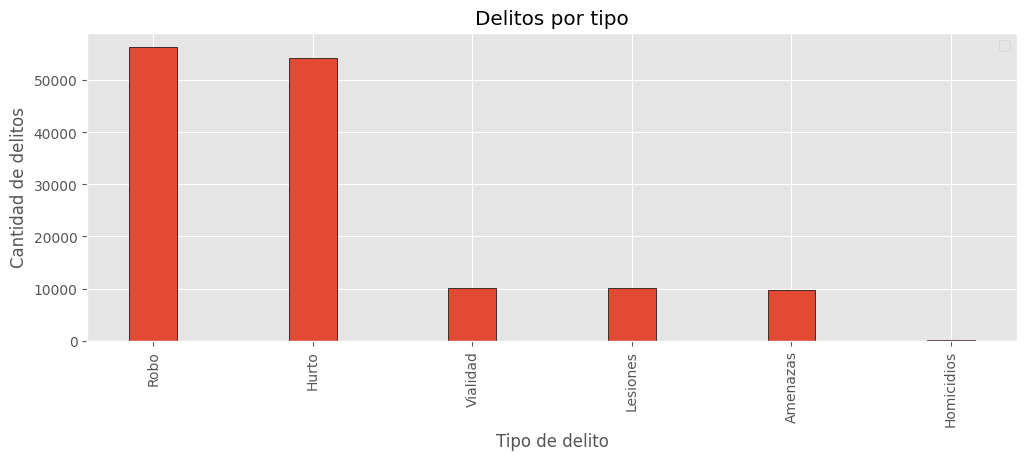

In [25]:
# Filtro por barrio y cuento la frecuencia
frec_tipo = df.groupby(["tipo"]).size()

# Convierto la serie en dataframe
df_frec_tipo = frec_tipo.to_frame('delitos')

# Ordeno el DataFrame de frecuencias por el número de delitos en orden descendente
df_frec_tipo = df_frec_tipo.sort_values(by='delitos', ascending=False)

# Elijo mis variables x e y
nombre_x = 'Tipo de delito'
nombre_y = 'Cantidad de delitos'
y = df_frec_tipo["delitos"]
x = df_frec_tipo.index

# Crea una figura y un conjunto de ejes
fig, ax = plt.subplots(figsize=(12, 4))

# Creo el gráfico
ax.bar(x, y, width = 0.3, edgecolor = 'black',)

# Etiqueto los ejes
ax.set_xlabel(f'{nombre_x}')
ax.set_ylabel(f'{nombre_y}')

# Agrego un título
ax.set_title('Delitos por tipo')

# Giro las etiquetas del eje x las hago más pequeñas
ax.tick_params(axis='x', rotation=90)

# Añado la leyenda al gráfico
plt.legend()

# Muestro el gráfico
plt.show()

Se filtraron los datos para poder representar los delitos por tipo ocurridos en la ciudad y es evidente la diferencia entre el robo y el hurto con los otros tipos de delitos registrados en la base de datos. Esto muestra los principales problemas que afectan la ciudad en cuanto a crimen se refiere y que deberían ser evaluados prioritariamente para su resolución.

### ¿Qué subtipo de delito se comete más en la ciudad?

/tmp/ipython-input-1420316727.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  frec_subtipo = df.groupby(["subtipo"]).size()
/tmp/ipython-input-1420316727.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


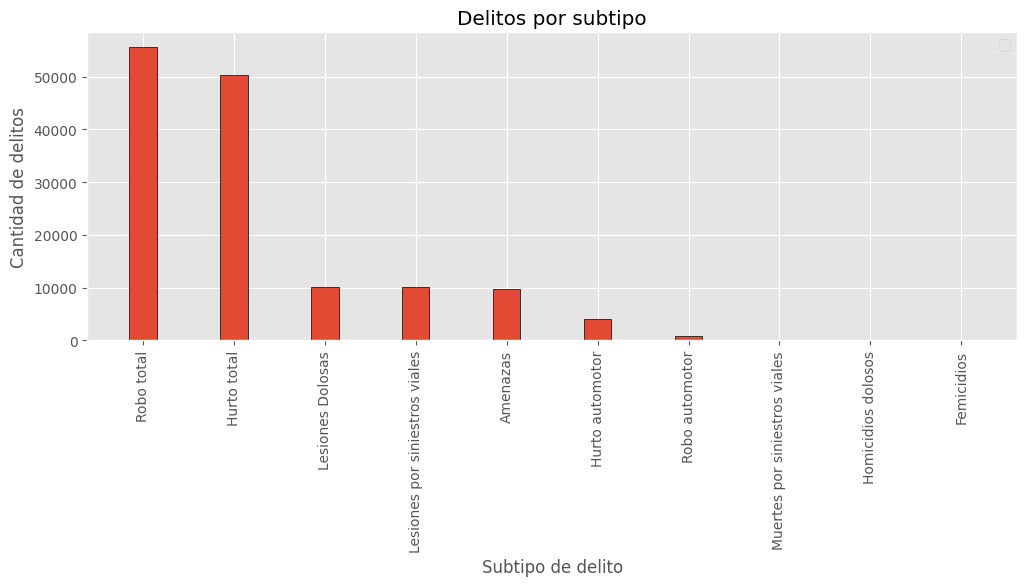

In [26]:
# Filtro por barrio y cuento la frecuencia
frec_subtipo = df.groupby(["subtipo"]).size()

# Convierto la serie en dataframe
df_frec_subtipo = frec_subtipo.to_frame('delitos')

# Ordeno el DataFrame de frecuencias por el número de delitos en orden descendente
df_frec_subtipo = df_frec_subtipo.sort_values(by='delitos', ascending=False)

# Elijo mis variables x e y
nombre_x = 'Subtipo de delito'
nombre_y = 'Cantidad de delitos'
y = df_frec_subtipo["delitos"]
x = df_frec_subtipo.index

# Crea una figura y un conjunto de ejes
fig, ax = plt.subplots(figsize=(12, 4))

# Creo el gráfico
ax.bar(x, y, width = 0.3, edgecolor = 'black',)

# Etiqueto los ejes
ax.set_xlabel(f'{nombre_x}')
ax.set_ylabel(f'{nombre_y}')

# Agrego un título
ax.set_title('Delitos por subtipo')

# Giro las etiquetas del eje x y hazlas más pequeñas
ax.tick_params(axis='x', rotation=90)

# Añado la leyenda al gráfico
plt.legend()

# Muestro el gráfico
plt.show()

NOTA: La suma de robo total con robo automotor y hurto total con hurto automotor da como resultado el total de hurtos y robos del gráfico anterior.

De igual manera que en el gráfico de delitos por tipo, se destaca el robo total y el hurto total como principal tipo de incidente ocurrido en la ciudad por mucho.

## Análisis geográfico.

### ¿En qué barrio se cometen más delitos?

/tmp/ipython-input-4197251400.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  frec_barrio = df.groupby(["barrio"]).size()


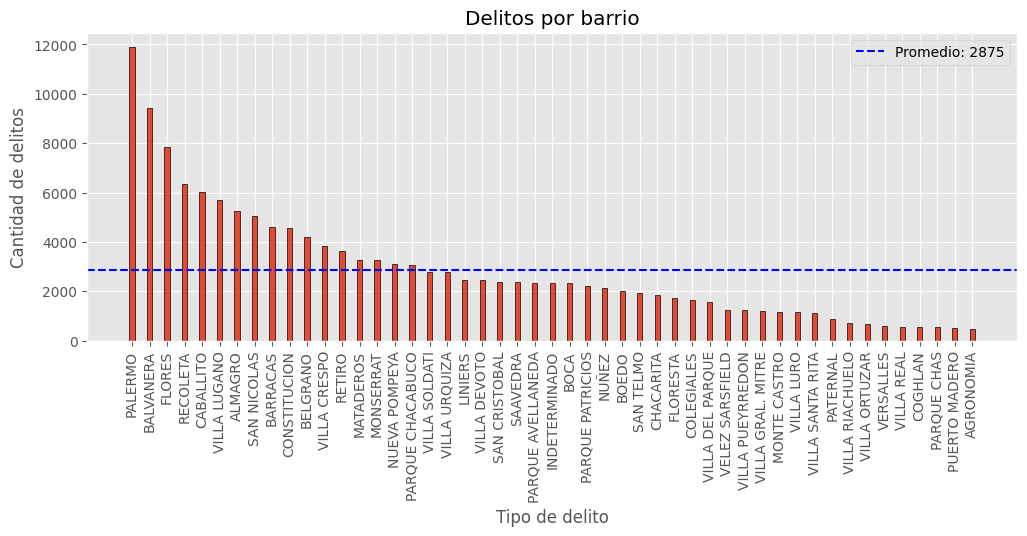

In [27]:
# Filtro por barrio y cuento la frecuencia
frec_barrio = df.groupby(["barrio"]).size()

# Convierto la serie en dataframe
df_frec_barrio = frec_barrio.to_frame('delitos')

# Ordeno el DataFrame de frecuencias por el número de delitos en orden descendente
df_frec_barrio = df_frec_barrio.sort_values(by='delitos', ascending=False)

#Elijo mis variables x e y
nombre_x = 'Tipo de delito'
nombre_y = 'Cantidad de delitos'
y = df_frec_barrio["delitos"]
x = df_frec_barrio.index

# Creo una figura y un conjunto de ejes
fig, ax = plt.subplots(figsize=(12, 4))

# Creo el gráfico
ax.bar(x, y, width = 0.3, edgecolor = 'black',)

# Etiqueto los ejes
ax.set_xlabel(f'{nombre_x}')
ax.set_ylabel(f'{nombre_y}')

# Agrego un título
ax.set_title('Delitos por barrio')

# Giro las etiquetas del eje x y hazlas más pequeñas
ax.tick_params(axis='x', rotation=90)

# Calculo el promedio por barrio de delitos de toda la ciudad
promedio = df_frec_barrio["delitos"].mean()

# Agrego una línea roja para marcar el valor promedio con una etiqueta
plt.axhline(promedio, color="blue", linestyle="--", label=f'Promedio: {promedio:.0f}')

# Añado la leyenda al gráfico
plt.legend()

# Muestro el gráfico
plt.show()

Se calculó el promedio de delitos en la ciudad y se comparó con el total de delitos cometidos en cada barrio de la ciudad. En la distribución de los incidentes se evidencian que hay zonas que han tenido más del triple de sucesos que el promedio. Esto podría deberse al movimiento de la población en la ciudad, ya que en el top 3 de barrios se encuentran importantes zonas comerciales como son la venta mayorista de mercadería en los barrios de Balvanera y Flores y la gran oferta de vida nocturna concentrada en el barrio de Palermo.

### Mapa que muestra los datos geoespaciales.
####Es posible filtrarlo por tipo de delito.

In [28]:
import folium
from folium.plugins import HeatMap
import numpy as np
import pandas as pd
from ipywidgets import interact, widgets

# Asignar los datos
data = df  # Datos de coordenadas y tipos de delitos aleatorios
df_heat = pd.DataFrame(data, columns=['latitud', 'longitud', 'tipo'])  # Convertir los datos a un DataFrame de pandas

# Elimino las filas enteras donde se registran valores nulos en la columna franja.
df_heat = df_heat.dropna(subset=['latitud'])

# Coordenadas de Buenos Aires
lat_buenos_aires = -34.6037
long_buenos_aires = -58.3816

# Función para generar y mostrar el mapa de calor según el tipo de delito seleccionado
def mostrar_heatmap(tipo_delito):
    # Filtrar datos según el tipo de delito seleccionado
    if tipo_delito == 'Todos':
        df_filtrado = df_heat
    else:
        df_filtrado = df_heat[df_heat['tipo'] == tipo_delito]

    # Crear un mapa centrado en una ubicación específica
    mapa = folium.Map(location=[lat_buenos_aires, long_buenos_aires], zoom_start=10)

    # Convertir los datos de coordenadas filtrados a una lista de listas [[lat, lon], [lat, lon], ...]
    heat_data = df_filtrado[['latitud', 'longitud']].values.tolist()

    # Añadir el mapa de calor al mapa
    HeatMap(heat_data).add_to(mapa)

    # Mostrar el mapa de calor
    display(mapa)

# Obtener la lista única de tipos de delitos y agregar 'Todos' como opción
tipos_de_delitos = ['Todos'] + df_heat['tipo'].unique().tolist()

# Crear un menú desplegable interactivo para seleccionar el tipo de delito
interact(mostrar_heatmap, tipo_delito=widgets.Dropdown(options=tipos_de_delitos, description='Tipo de Delito:'));


interactive(children=(Dropdown(description='Tipo de Delito:', options=('Todos', 'Robo', 'Amenazas', 'Lesiones'…

Esta es una herramienta visual que permite filtrar por tipo de delito y muestra donde se cometió el hecho.

## Análisis temporal

### ¿En qué mes se cometen más delitos?

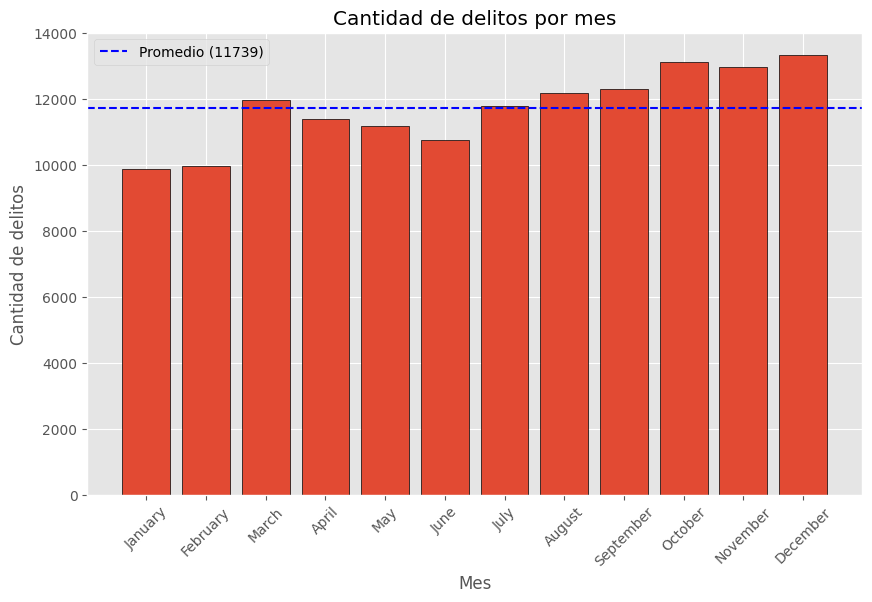

In [29]:
# Convertir la columna 'fecha' a tipo datetime
df['fecha'] = pd.to_datetime(df['fecha'])

# Crear nueva columna 'Mes'
df['Mes'] = df['fecha'].dt.month

# Calcular la frecuencia total de delitos por mes
delitos_por_mes = df.groupby('Mes').size().reset_index(name='Frecuencia')

# Calcular el promedio de delitos por mes
promedio_delitos_por_mes = delitos_por_mes['Frecuencia'].mean()

# Crear el gráfico de barras para la frecuencia total de delitos por mes
plt.figure(figsize=(10, 6))
plt.bar(delitos_por_mes['Mes'], delitos_por_mes['Frecuencia'], edgecolor='black')

# Agregar línea para el promedio de delitos por mes
plt.axhline(y=promedio_delitos_por_mes, color='blue', linestyle='--', label=f'Promedio ({promedio_delitos_por_mes:.0f})')

# Configurar etiquetas y leyenda
plt.title('Cantidad de delitos por mes')
plt.xlabel('Mes')
plt.ylabel('Cantidad de delitos')
plt.xticks(range(1, 13), [calendar.month_name[i].capitalize() for i in range(1, 13)], rotation=45)
plt.legend()

# Mostrar el gráfico
plt.show()


NOTA: No he podido encontrar la manera de poner los nombres en español con una función. No quise ponerlos con una lista uno a uno. De ser necesario lo haré así.

 En este gráfico se agruparon los delitos reportados sin importar su tipo para tener una vista general del comportamiento en volumen de la criminalidad durante el año. En el msimo orden se calculó el promedio de delitos por mes y se dispusieron las barras de manera que sea fácil la comparación.

 Aquí se encontró que en los meses de enero, febrero y junio se reducen la cantidad de incidentes ocurridos. Las vacaciones pueden ser un motivo por el cuál se da este comportamiento, ya que la población tiende a salir de la ciudad.

En el último trimestre del año se nota el aumento en la cantidad de delitos. Una de las razones puede ser el crecimiento temporal en las actividades comerciales generadas por la época navideña.

### ¿A qué hora del día se comete más cada tipo de delito?

/tmp/ipython-input-3636301876.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  delitos_por_tipo_barrio_franja = df.groupby(["franja", "tipo"]).size().sort_values(ascending=False)


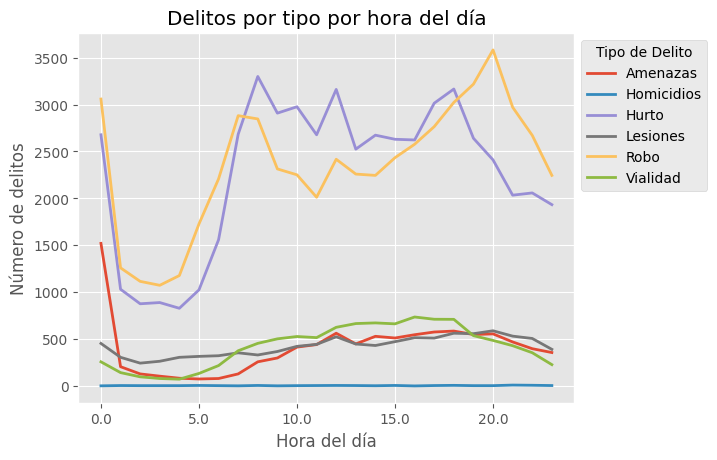

In [30]:
# Cuento el número de delitos por tipo y dia
delitos_por_tipo_barrio_franja = df.groupby(["franja", "tipo"]).size().sort_values(ascending=False)

# Creo el gráfico de barras
fig, ax = plt.subplots()
delitos_por_tipo_barrio_franja.unstack().plot.line(ax=ax, linewidth=2)

# Agrego títulos y etiquetas
ax.set_title("Delitos por tipo por hora del día")
ax.set_xlabel("Hora del día")
ax.set_ylabel("Número de delitos")
plt.legend(title='Tipo de Delito', bbox_to_anchor=(1, 1))

# Muestra el gráfico
plt.show()

* Podemos ver que de 1 a 4 hs se evidencia un marcado descenso en el número de incidentes en todos los tipos estudiados. Esto se debe a que son las de 20 de la mayoría de las personas bajando la probabilidad de ocurrencia por la disminución del movimiento de las personas.

* Entre las 8 y las 20 hs se nota un incremento muy marcado en todos los tipos de delitos debido a que son las horas de mayor circulación de la población que desarrolla sus actividades cotidianas.
No obstante, los robos y hurtos empiezan a aumentar desde las 4 hs, hora en la que muchos salen a tomar el transporte para poder llegar a sus lugares de trabajo o estudio.